"""
LSTM_Multivariate_Bajulmati_TMA_v2.py

# LSTM Multivariate + Feature-wise Attention — Prediksi TMA Bendungan Bajulmati
## Bendungan Bajulmati 2018–2026 | BBWS Brantas — Kementerian PUPR
---

### Arsitektur
```
Input (48, 5) → LSTM(128) → FeatureWiseAttention → LSTM(64) → LSTM(32)
→ Dense(32) → Dense(16) → Dense(1, linear) → delta_tma (scaled)
```

### Daftar Isi
 1. Setup & Import
 2. Fungsi Metrik
 3. Load Dataset
 4. Rekayasa Fitur & Definisi Target (on-the-fly)
 5. EDA
 6. Scaling
 7. Sliding Window
 8. Train / Validation / Test Split
 9. Arsitektur Model + FeatureWiseAttention
10. Training
11. Plot Training History
12. Prediksi, Inverse Transform & Rekonstruksi TMA Absolut
13. Evaluasi Regresi
14. Evaluasi Early Warning (Klasifikasi)
15. Visualisasi Attention Weight per Fitur
16. Visualisasi Prediksi
17. Simpan Semua Output

In [ ]:
# =============================================================================
# 1. SETUP & IMPORT
# =============================================================================

import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Layer
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Output folder
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'Pandas version     : {pd.__version__}')
print(f'Output dir         : {os.path.abspath(MODEL_DIR)}')

TensorFlow version : 2.20.0
NumPy version      : 2.0.2
Pandas version     : 2.2.2
Output dir         : /content/models


In [ ]:
# =============================================================================
# 2. FUNGSI METRIK
# =============================================================================

def nash_sutcliffe_efficiency(y_true, y_pred):
    """NSE: 1=sempurna, <0=lebih buruk dari mean baseline"""
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - num / den) if den != 0 else float('-inf')

def mape(y_true, y_pred, eps=1e-8):
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100)

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot != 0 else float('-inf')

def compute_regression_metrics(y_true, y_pred, label=''):
    """Menghitung dan mencetak metrik regresi (RMSE, MAE, MAPE, R², NSE)."""
    metrics = {
        'rmse': rmse(y_true, y_pred),
        'mae' : mae(y_true, y_pred),
        'mape': mape(y_true, y_pred),
        'r2'  : r2(y_true, y_pred),
        'nse' : nash_sutcliffe_efficiency(y_true, y_pred),
    }
    if label:
        print(f'\n{"="*45}')
        print(f'  {label}')
        print(f'{"="*45}')
        print(f'  RMSE : {metrics["rmse"]:.4f} m')
        print(f'  MAE  : {metrics["mae"]:.4f} m')
        print(f'  MAPE : {metrics["mape"]:.4f} %')
        print(f'  R²   : {metrics["r2"]:.4f}')
        print(f'  NSE  : {metrics["nse"]:.4f}')
    return metrics

def compute_classification_metrics(y_true, y_pred, threshold, label=''):
    """Early warning metrics — TMA absolut di-binarisasi terhadap threshold."""
    bin_true = (y_true >= threshold).astype(int)
    bin_pred = (y_pred >= threshold).astype(int)
    cm = confusion_matrix(bin_true, bin_pred)
    metrics = {
        'accuracy' : float(accuracy_score(bin_true, bin_pred)),
        'recall'   : float(recall_score(bin_true, bin_pred, zero_division=0)),
        'precision': float(precision_score(bin_true, bin_pred, zero_division=0)),
        'f1'       : float(f1_score(bin_true, bin_pred, zero_division=0)),
        'cm'       : cm,
        'bin_true' : bin_true,
        'bin_pred' : bin_pred,
    }
    if label:
        print(f'\n--- Early Warning Metrics ({label}) ---')
        print(f'  Threshold : {threshold:.3f} m')
        print(f'  Accuracy  : {metrics["accuracy"]:.4f}')
        print(f'  Recall    : {metrics["recall"]:.4f}')
        print(f'  Precision : {metrics["precision"]:.4f}')
        print(f'  F1-Score  : {metrics["f1"]:.4f}')
    return metrics

In [ ]:
# =============================================================================
# 3. LOAD DATASET
# =============================================================================

# Path dataset (Upload dulu ges terus copy pathnya)
DATASET_PATH = '/content/Bajulmati_Dataset_2018_2026_Imputed.xlsx'

df = pd.read_excel(DATASET_PATH, header=2)

# Standarisasi jam_kode: nilai 16 → 17 (jam 16:00 ≈ 17:00 disamakan semua)
df['jam_kode'] = df['jam_kode'].replace(16, 17)

# Parse datetime dan urutkan
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

print(f'Dataset dimuat  : {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'Rentang waktu   : {df["datetime"].min()} → {df["datetime"].max()}')
print(f'Jumlah null     : {df.isnull().sum().sum()}')
print(f'\nKolom tersedia  : {list(df.columns)}')

Dataset dimuat  : 8558 baris × 17 kolom
Rentang waktu   : 2018-01-01 07:00:00 → 2026-02-28 17:00:00
Jumlah null     : 3

Kolom tersedia  : ['datetime', 'tahun', 'bulan', 'tma_m', 'cuaca', 'cuaca_kode', 'jam_kode', 'curah_hujan_mm', 'smd_kanan_q_ls', 'smd_kiri_q_ls', 'tma_lag1', 'tma_lag2', 'tma_lag3', 'delta_tma', 'tma_rolling_mean_3', 'flag_CH_imputed', 'flag_SMD_imputed']


In [ ]:
# =============================================================================
# 4. REKAYASA FITUR & DEFINISI TARGET
# =============================================================================
# [PERUBAHAN DARI v1]
# Target baru: delta_tma (bukan tma_m absolut)
# Alasan: memaksa model belajar dinamika perubahan air. Gradient backprop akan
#         menyalahkan fitur relevan (curah_hujan, cuaca, smd), bukan lag statis.
#
# Fitur dihapus: tma_lag1, tma_lag2, tma_lag3, tma_rolling_mean_3
#   → Fitur ini berkorelasi hampir 1.0 dengan tma_m absolut yang menyebabkan
#  lazy learning, intinya males belajar fitur lain mesinnya.
#
# Fitur baru / transformasi:
#   - smd_avg         = rata-rata smd_kanan & smd_kiri (keduanya redundan, r=0.99)
#   - curah_hujan_log = log1p(curah_hujan_mm)  (mengurangi skewness hujan)
#   - delta_tma_lag1  = delta_tma.shift(1)      (konsisten secara matematis)

TARGET_COL   = 'delta_tma'      # [BARU] prediksi perubahan TMA, bukan nilai absolut

FEATURE_COLS = [
    'curah_hujan_log',   # [BARU] log1p(curah_hujan_mm)
    'cuaca_kode',        # [SAMA]
    'smd_avg',           # [BARU] rata-rata smd_kanan dan smd_kiri
    'delta_tma_lag1',    # [BARU] delta_tma.shift(1) — menggantikan tma_lag1/2/3
    'jam_kode',          # [SAMA]
]

# Rekayasa fitur
df_model = df[[
    'datetime', 'tahun',
    'tma_m',             # disimpan untuk rekonstruksi TMA absolut & threshold
    'delta_tma',         # target
    'curah_hujan_mm',    # sebelum log transform
    'cuaca_kode',
    'smd_kanan_q_ls',
    'smd_kiri_q_ls',
    'jam_kode',
]].copy()

# 1. smd_avg: gabungkan dua SMD yang sangat berkorelasi (r=0.99)
df_model['smd_avg'] = (df_model['smd_kanan_q_ls'] + df_model['smd_kiri_q_ls']) / 2.0

# 2. curah_hujan_log: log transform sebelum scaling untuk mengurangi skewness
df_model['curah_hujan_log'] = np.log1p(df_model['curah_hujan_mm'])

# 3. delta_tma_lag1: delta_tma satu langkah sebelumnya (lebih konsisten
#    secara matematis daripada tma_lag1 yang merupakan nilai absolut)
df_model['delta_tma_lag1'] = df_model['delta_tma'].shift(1)

# Hapus baris pertama yang mengandung NaN dari shift
df_model = df_model.dropna(subset=['delta_tma_lag1']).reset_index(drop=True)

# Kolom lengkap untuk scaling: target di index 0, fitur menyusul
ALL_COLS = [TARGET_COL] + FEATURE_COLS   # 6 kolom total

print(f'\n{"="*50}')
print(f'TARGET_COL  : {TARGET_COL}')
print(f'FEATURE_COLS: {FEATURE_COLS}')
print(f'ALL_COLS    : {ALL_COLS}')
print(f'{"="*50}')
print(f'\nShape df_model : {df_model.shape}')
print(f'Null setelah rekayasa fitur: {df_model[ALL_COLS].isnull().sum().sum()}')
df_model[ALL_COLS].describe()


TARGET_COL  : delta_tma
FEATURE_COLS: ['curah_hujan_log', 'cuaca_kode', 'smd_avg', 'delta_tma_lag1', 'jam_kode']
ALL_COLS    : ['delta_tma', 'curah_hujan_log', 'cuaca_kode', 'smd_avg', 'delta_tma_lag1', 'jam_kode']

Shape df_model : (8557, 12)
Null setelah rekayasa fitur: 0


,delta_tma,curah_hujan_log,cuaca_kode,smd_avg,delta_tma_lag1,jam_kode
count,8557.000000,8557.000000,8557.000000,8557.000000,8557.000000,8557.000000
mean,0.000002,0.493032,1.728994,6.241869,0.000004,11.998247
std,0.109715,1.021122,0.943503,7.990036,0.109715,4.147454
min,-2.950000,0.000000,1.000000,2.570400,-2.950000,7.000000
25%,-0.010000,0.000000,1.000000,3.774050,-0.010000,7.000000
50%,0.000000,0.000000,1.000000,4.351050,0.000000,12.000000
75%,0.000000,0.405465,2.000000,4.845950,0.000000,17.000000
max,3.550000,5.438079,4.000000,43.782800,3.550000,17.000000


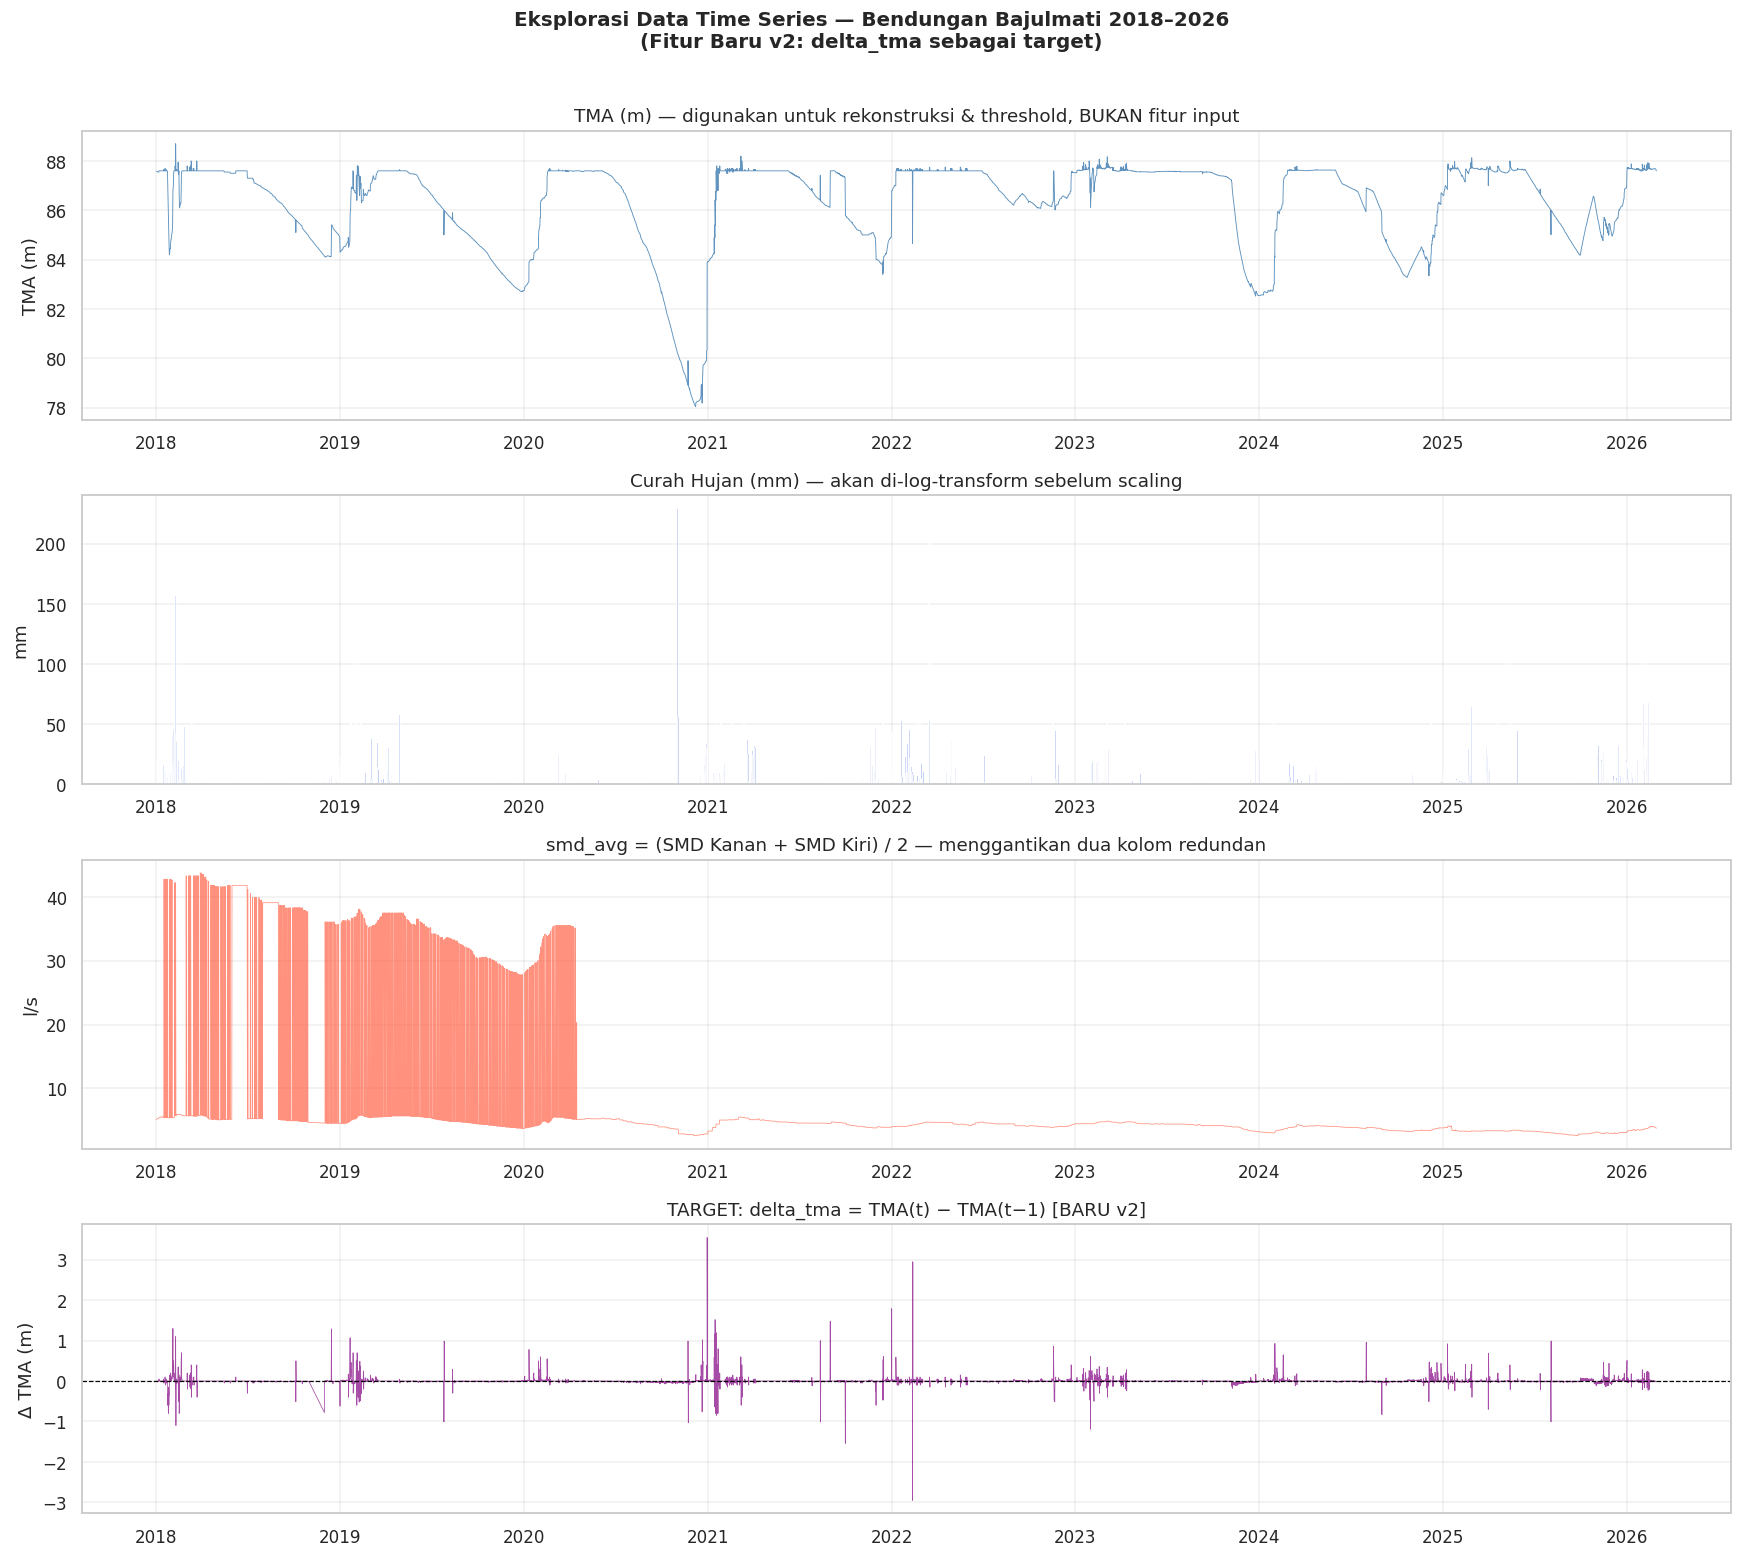

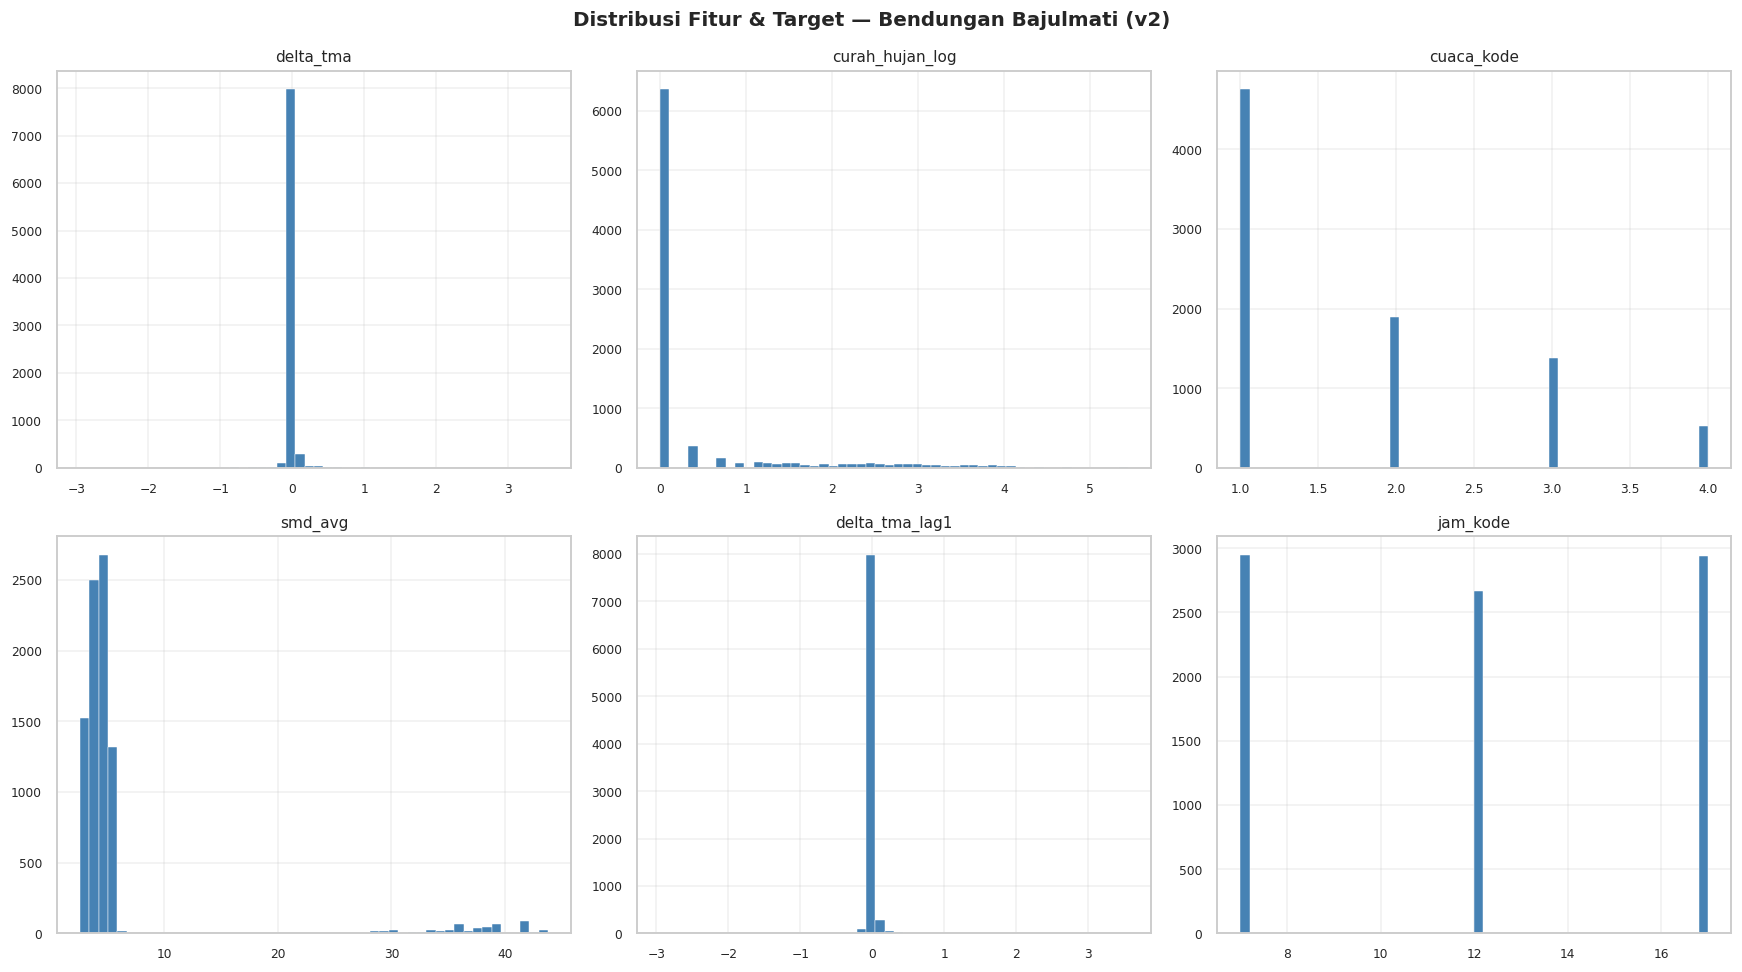

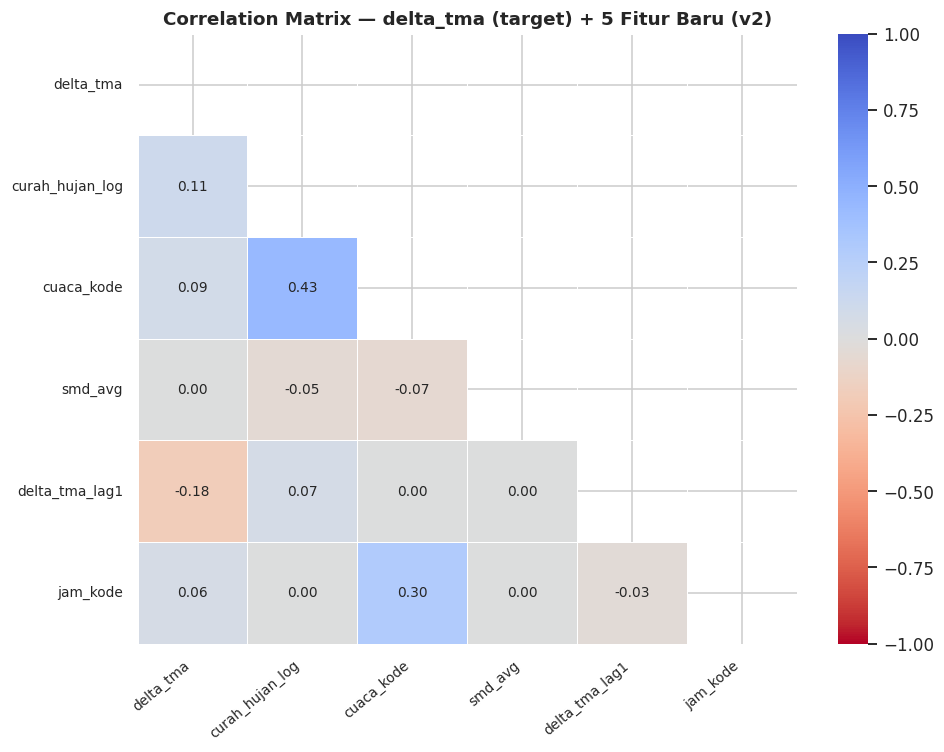


Korelasi terhadap delta_tma (target) — urutan menurun:
curah_hujan_log    0.109778
cuaca_kode         0.085884
jam_kode           0.058744
smd_avg            0.003140
delta_tma_lag1    -0.183535


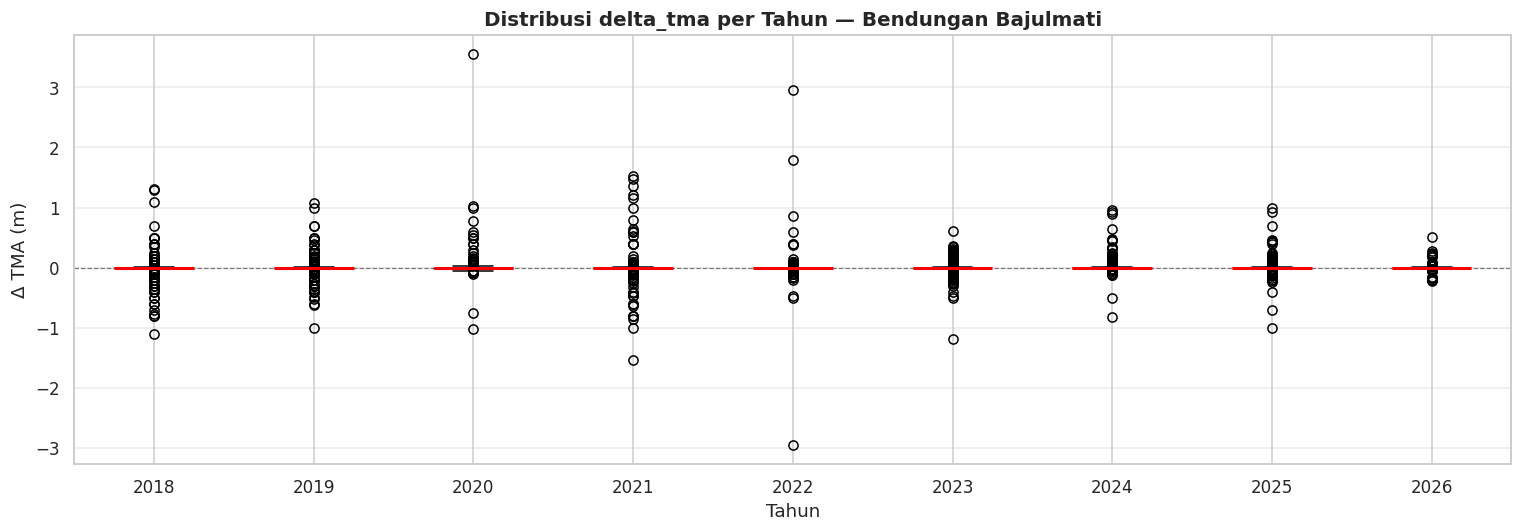

In [ ]:
# =============================================================================
# 5. EDA (EKSPLORASI DATA)
# =============================================================================

# --- 5a. Time Series Plot ---
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
fig.suptitle('Eksplorasi Data Time Series — Bendungan Bajulmati 2018–2026\n'
             '(Fitur Baru v2: delta_tma sebagai target)',
             fontsize=13, fontweight='bold', y=1.01)

dt = df_model['datetime']

axes[0].plot(dt, df_model['tma_m'], color='steelblue', lw=0.6, alpha=0.85)
axes[0].set_title('TMA (m) — digunakan untuk rekonstruksi & threshold, BUKAN fitur input')
axes[0].set_ylabel('TMA (m)')

axes[1].bar(dt, df_model['curah_hujan_mm'], color='royalblue', alpha=0.5, width=0.3)
axes[1].set_title('Curah Hujan (mm) — akan di-log-transform sebelum scaling')
axes[1].set_ylabel('mm')

axes[2].plot(dt, df_model['smd_avg'], color='tomato', lw=0.5, alpha=0.7)
axes[2].set_title('smd_avg = (SMD Kanan + SMD Kiri) / 2 — menggantikan dua kolom redundan')
axes[2].set_ylabel('l/s')

axes[3].plot(dt, df_model['delta_tma'], color='purple', lw=0.5, alpha=0.7)
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_title('TARGET: delta_tma = TMA(t) − TMA(t−1) [BARU v2]')
axes[3].set_ylabel('Δ TMA (m)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_timeseries.png', bbox_inches='tight')
plt.show()

# --- 5b. Distribusi setiap fitur dan target ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribusi Fitur & Target — Bendungan Bajulmati (v2)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(ALL_COLS):
    axes[i].hist(df_model[col].dropna(), bins=50, color='steelblue',
                 edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(alpha=0.3)
    axes[i].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_distribusi.png', bbox_inches='tight')
plt.show()

# --- 5c. Correlation Heatmap (target + fitur baru) ---
plt.figure(figsize=(9, 7))
corr = df_model[ALL_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm_r',
    vmin=-1, vmax=1, mask=mask, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix — delta_tma (target) + 5 Fitur Baru (v2)',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_correlation.png', bbox_inches='tight')
plt.show()

print('\nKorelasi terhadap delta_tma (target) — urutan menurun:')
print(corr['delta_tma'].drop('delta_tma').sort_values(ascending=False).to_string())

# --- 5d. Boxplot delta_tma per Tahun ---
plt.figure(figsize=(14, 5))
years = df_model['tahun'].astype(int)
data_by_year = [df_model.loc[years == y, 'delta_tma'].values for y in sorted(years.unique())]
plt.boxplot(data_by_year, labels=sorted(years.unique()),
            patch_artist=True,
            boxprops=dict(facecolor='purple', alpha=0.4),
            medianprops=dict(color='red', linewidth=2))
plt.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
plt.title('Distribusi delta_tma per Tahun — Bendungan Bajulmati', fontsize=13, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Δ TMA (m)')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/eda_boxplot_tahun.png', bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# 6. SCALING
# =============================================================================
#
# [PERUBAHAN DARI v1]
# scaler_all : fit pada semua kolom ALL_COLS (delta_tma + 5 fitur)
# scaler_target: fit khusus pada delta_tma (bukan tma_m) → untuk inverse transform
#
# curah_hujan_log sudah di-transform sebelum scaling (Section 4).
# Scaling TIDAK diterapkan pada tma_m karena hanya dipakai untuk rekonstruksi.

print('Scaling data dengan MinMaxScaler (0–1)...')

data_values = df_model[ALL_COLS].values   # shape: (N, 6) — target di kolom 0

# Scaler semua kolom: delta_tma (index 0) + 5 fitur
scaler_all = MinMaxScaler(feature_range=(0, 1))
scaled_all = scaler_all.fit_transform(data_values)

# Scaler khusus target (delta_tma) untuk inverse transform prediksi
scaler_target = MinMaxScaler(feature_range=(0, 1))
scaler_target.fit(data_values[:, 0].reshape(-1, 1))

print(f'Data shape setelah scaling : {scaled_all.shape}')
print(f'Range scaled data          : [{scaled_all.min():.3f}, {scaled_all.max():.3f}]')
print(f'Kolom urutan ALL_COLS      : {ALL_COLS}')
print(f'Kolom 0 (target)           : {ALL_COLS[0]} (dipakai scaler_target)')


Scaling data dengan MinMaxScaler (0–1)...
Data shape setelah scaling : (8557, 6)
Range scaled data          : [0.000, 1.000]
Kolom urutan ALL_COLS      : ['delta_tma', 'curah_hujan_log', 'cuaca_kode', 'smd_avg', 'delta_tma_lag1', 'jam_kode']
Kolom 0 (target)           : delta_tma (dipakai scaler_target)


In [ ]:
# =============================================================================
# 7. SLIDING WINDOW
# =============================================================================
#
# [PERUBAHAN DARI v1]
# LOOK_BACK: 90 → 48 timestep
#   - 48 obs × (1/3 obs per jam) = 16 hari
#   - Secara hidrologis, respons debit terhadap curah hujan biasanya 3–14 hari
#   - 48 lebih relevan dan mengurangi komputasi tanpa kehilangan konteks penting
#
# X: (samples, 48, 5) — 5 fitur saja (kolom 1–5 dari scaled_all)
# Y: (samples,)       — delta_tma scaled (kolom 0 dari scaled_all)

LOOK_BACK = 48   # [BARU] 48 timestep ≈ 16 hari (3 obs/hari)

def create_multivariate_sequences(dataset, look_back):
    """
    Sliding window untuk LSTM Multivariate.

    Parameters
    ----------
    dataset   : np.ndarray, shape (N, n_cols)
                Kolom 0 = target (delta_tma scaled)
                Kolom 1..n = fitur input
    look_back : int

    Returns
    -------
    X : (samples, look_back, n_features)  — fitur saja (kolom 1..)
    Y : (samples,)                        — target (kolom 0) pada t+1
    """
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i : i + look_back, 1:])   # kolom fitur (bukan target)
        Y.append(dataset[i + look_back, 0])          # target = kolom 0, step berikutnya
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_all, y_all = create_multivariate_sequences(scaled_all, LOOK_BACK)

# Simpan nilai tma_m untuk rekonstruksi (Section 12)
# tma_prev[i] = tma_m pada t-1 saat sequence i memprediksi step ke-LOOK_BACK
# → digunakan: tma_pred(t) = tma_actual(t-1) + delta_pred(t)
tma_m_raw = df_model['tma_m'].values
tma_prev_all  = tma_m_raw[LOOK_BACK - 1 : len(df_model) - 1]  # TMA pada t-1
tma_true_all  = tma_m_raw[LOOK_BACK :]                          # TMA aktual pada t

print(f'LOOK_BACK       : {LOOK_BACK} timestep (~{LOOK_BACK//3} hari)')
print(f'X_all shape     : {X_all.shape}  → (samples, look_back, n_features)')
print(f'y_all shape     : {y_all.shape}  → (samples,) delta_tma scaled')
print(f'tma_prev_all    : {tma_prev_all.shape}  → TMA aktual pada t-1 (untuk rekonstruksi)')
print(f'tma_true_all    : {tma_true_all.shape}  → TMA aktual pada t (untuk evaluasi)')
n_features = X_all.shape[2]  # 5
print(f'n_features      : {n_features}')

LOOK_BACK       : 48 timestep (~16 hari)
X_all shape     : (8509, 48, 5)  → (samples, look_back, n_features)
y_all shape     : (8509,)  → (samples,) delta_tma scaled
tma_prev_all    : (8509,)  → TMA aktual pada t-1 (untuk rekonstruksi)
tma_true_all    : (8509,)  → TMA aktual pada t (untuk evaluasi)
n_features      : 5


Total sampel : 8509
Train        :  5956 sampel (s/d 2023-10-29)
Validation   :  1276 sampel (s/d 2024-12-28)
Test         :  1277 sampel


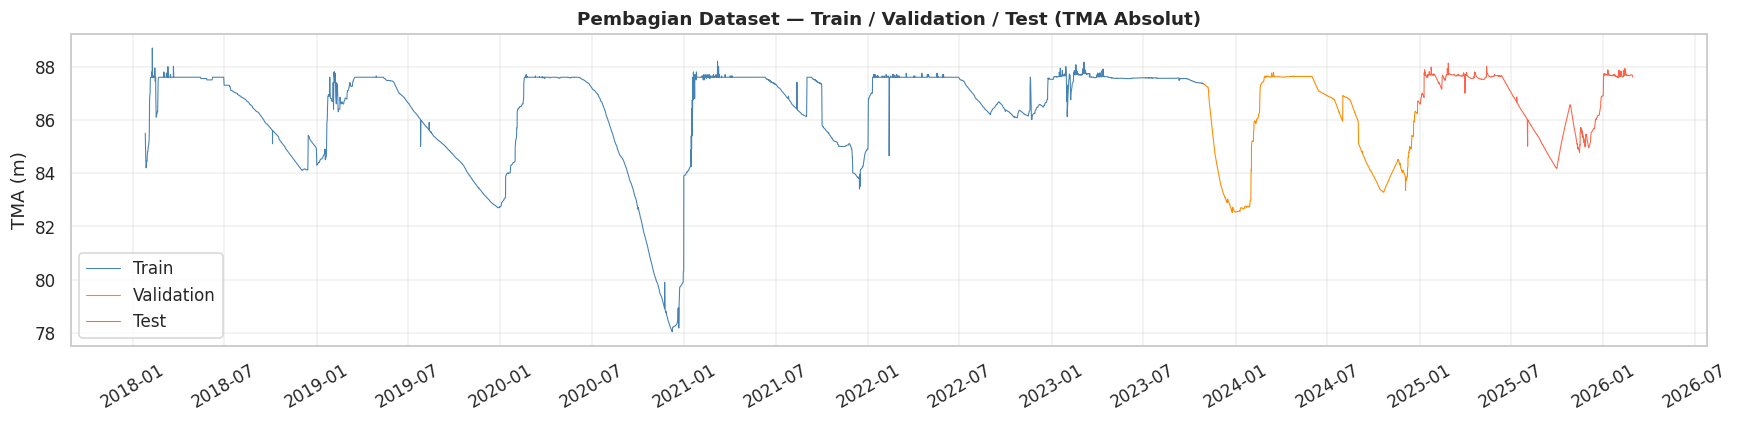

In [ ]:
# =============================================================================
# 8. TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

# Split temporal (tidak random) — 70 / 15 / 15
n         = len(X_all)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X_all[:train_end],        y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

# TMA aktual untuk rekonstruksi & evaluasi regresi di setiap split
tma_prev_train = tma_prev_all[:train_end]
tma_prev_val   = tma_prev_all[train_end:val_end]
tma_prev_test  = tma_prev_all[val_end:]

tma_true_train = tma_true_all[:train_end]
tma_true_val   = tma_true_all[train_end:val_end]
tma_true_test  = tma_true_all[val_end:]

# Datetime index (digeser LOOK_BACK)
dt_all   = df_model['datetime'].values[LOOK_BACK:]
dt_train = dt_all[:train_end]
dt_val   = dt_all[train_end:val_end]
dt_test  = dt_all[val_end:]

# Simpan batas split untuk metadata
train_end_date = pd.Timestamp(dt_train[-1]).strftime('%Y-%m-%d')
val_end_date   = pd.Timestamp(dt_val[-1]).strftime('%Y-%m-%d')

print(f'Total sampel : {n}')
print(f'Train        : {len(X_train):5d} sampel (s/d {train_end_date})')
print(f'Validation   : {len(X_val):5d} sampel (s/d {val_end_date})')
print(f'Test         : {len(X_test):5d} sampel')

# Visualisasi split (menggunakan TMA absolut untuk konteks visual)
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(dt_train, tma_true_train, color='steelblue',  lw=0.7, label='Train')
ax.plot(dt_val,   tma_true_val,   color='darkorange', lw=0.7, label='Validation')
ax.plot(dt_test,  tma_true_test,  color='tomato',     lw=0.7, label='Test')
ax.set_title('Pembagian Dataset — Train / Validation / Test (TMA Absolut)', fontsize=12, fontweight='bold')
ax.set_ylabel('TMA (m)')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/split_visualisasi.png', bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# 9. ARSITEKTUR MODEL LSTM + FEATUREWISEATTENTION
# =============================================================================
#
# [PERUBAHAN DARI v1]
# - Input shape: (48, 5) — bukan (90, 11)
# - Output layer: Dense(1) tanpa aktivasi (linear) karena delta bisa negatif
# - Nama model diupdate ke v2
#
# Mengapa Feature-wise Attention?
# Setelah target diubah ke delta_tma, secara teori bobot attention akan
# redistribusi ke fitur eksternal (curah_hujan, cuaca, smd) karena fitur lag
# tidak lagi informatif terhadap target perubahan TMA.

class FeatureWiseAttention(Layer):
    """
    Feature-wise Attention Mechanism.

    Cara kerja:
    1. Input LSTM: shape (batch, timesteps, lstm_units)
    2. Linear projection ke n_features: (batch, timesteps, n_features)
    3. Softmax per timestep → bobot attention per fitur
    4. Multiply bobot dengan input asli (element-wise broadcast)
    5. Output: weighted representation (batch, T, n_features) + alpha (untuk visualisasi)
    """

    def __init__(self, n_features, **kwargs):
        super().__init__(**kwargs)
        self.n_features = n_features

    def build(self, input_shape):
        # input_shape: (batch, timesteps, lstm_units)
        lstm_units = input_shape[-1]
        self.W = self.add_weight(
            name='attention_W',
            shape=(lstm_units, self.n_features),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_b',
            shape=(self.n_features,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)

    def call(self, lstm_output, original_input):
        """
        lstm_output   : (batch, timesteps, lstm_units)
        original_input: (batch, timesteps, n_features)
        """
        # 1. Proyeksi: (batch, T, lstm_units) → (batch, T, n_features)
        score = tf.matmul(lstm_output, self.W) + self.b   # (batch, T, n_features)

        # 2. Softmax per timestep → bobot attention per fitur
        alpha = tf.nn.softmax(score, axis=-1)              # (batch, T, n_features)

        # 3. Terapkan bobot ke input asli (element-wise)
        weighted = alpha * original_input                  # (batch, T, n_features)

        self.last_attention_weights = alpha
        return weighted, alpha

    def get_config(self):
        config = super().get_config()
        config.update({'n_features': self.n_features})
        return config


def build_model(look_back, n_features):
    """
    Arsitektur LSTM Multivariate + Feature-wise Attention (v2):
      Input(look_back=48, n_features=5)
      → LSTM(128, return_sequences=True) + Dropout(0.2)
      → FeatureWiseAttention(n_features=5)
      → LSTM(64,  return_sequences=True) + Dropout(0.2)
      → LSTM(32,  return_sequences=False) + Dropout(0.2)
      → Dropout(0.1)
      → Dense(32, relu)
      → Dense(16, relu)
      → Dense(1, linear)  ← [BARU] linear karena delta_tma bisa negatif

    Output: [prediksi_delta, attention_weights]
    """
    inputs = Input(shape=(look_back, n_features), name='input_sequence')

    # Layer 1: LSTM pertama
    x = LSTM(128, return_sequences=True, name='lstm_1')(inputs)
    x = Dropout(0.2, name='dropout_1')(x)

    # Layer 2: Feature-wise Attention
    attn_layer = FeatureWiseAttention(n_features=n_features, name='feature_attention')
    x, attention_weights = attn_layer(x, inputs)

    # Layer 3: LSTM kedua
    x = LSTM(64, return_sequences=True, name='lstm_2')(x)
    x = Dropout(0.2, name='dropout_2')(x)

    # Layer 4: LSTM ketiga
    x = LSTM(32, return_sequences=False, name='lstm_3')(x)
    x = Dropout(0.2, name='dropout_3')(x)

    # Dense layers
    x = Dropout(0.1, name='dropout_pre_dense')(x)
    x = Dense(32, activation='relu', name='dense_1')(x)
    x = Dense(16, activation='relu', name='dense_2')(x)

    # [BARU] Output linear: delta_tma bisa negatif (TMA turun)
    output = Dense(1, activation='linear', name='output')(x)

    model = Model(
        inputs=inputs,
        outputs=[output, attention_weights],
        name='LSTM_FeatureAttention_v2_delta'
    )
    return model, attn_layer


model, attn_layer = build_model(LOOK_BACK, n_features)

# Compile: loss hanya untuk output prediksi (attention = dummy, tidak di-optimasi)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=['mse', None],
    metrics=[['mae'], []]
)

model.summary()

Model: "LSTM_FeatureAttention_v2_delta"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 48, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 48, 128)   │     68,608 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48, 128)   │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_attention   │ [(None, 48, 5),   │        645 │ dropout_1[0][0],  │
│ (FeatureWiseAttent… │ (None, 48, 5)]    │            │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 48, 64)    │     17,920 │ feature_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 48, 64)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 32)        │     12,416 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_pre_dense   │ (None, 32)        │          0 │ dropout_3[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,056 │ dropout_pre_dens… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 101,190 (395.27 KB)

 Trainable params: 101,190 (395.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =============================================================================
# 10. TRAINING
# =============================================================================

EPOCHS     = 100
BATCH_SIZE = 64

callbacks = [
    EarlyStopping(
        monitor='val_output_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    ReduceLROnPlateau(
        monitor='val_output_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        filepath=f'{MODEL_DIR}/best_model.keras',
        monitor='val_output_loss',
        save_best_only=True,
        verbose=0,
        mode='min'
    ),
]

# Dummy target untuk output attention (shape: samples, LOOK_BACK, n_features)
dummy_train = np.zeros((len(y_train), LOOK_BACK, n_features), dtype=np.float32)
dummy_val   = np.zeros((len(y_val),   LOOK_BACK, n_features), dtype=np.float32)

print(f'Memulai training... ({EPOCHS} epoch max, batch_size={BATCH_SIZE})')
print(f'Target          : {TARGET_COL} (delta TMA, bukan TMA absolut)')
print(f'EarlyStopping patience=15 | ReduceLR patience=7')
print(f'Model akan disimpan ke: {MODEL_DIR}/best_model.keras')
print('='*60)

history = model.fit(
    X_train,
    [y_train, dummy_train],
    validation_data=(X_val, [y_val, dummy_val]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

epochs_trained = len(history.history['loss'])
print(f'\nTraining selesai. Epoch dijalankan: {epochs_trained}')


Memulai training... (100 epoch max, batch_size=64)
Target          : delta_tma (delta TMA, bukan TMA absolut)
EarlyStopping patience=15 | ReduceLR patience=7
Model akan disimpan ke: models/best_model.keras
Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - loss: 0.0222 - output_mae: 0.0993 - val_loss: 2.4364e-04 - val_output_mae: 0.0118 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - loss: 0.0021 - output_mae: 0.0343 - val_loss: 9.3303e-04 - val_output_mae: 0.0289 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - loss: 0.0013 - output_mae: 0.0257 - val_loss: 5.5502e-04 - val_output_mae: 0.0214 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - loss: 8.8826e-04 - output_mae: 0.0202 - val_loss: 5.9474e-04 - val_output_mae: 0.0222 - learning_rate: 0.0010
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - loss: 6.0824e-04 - output_mae: 0.0145 - val_loss: 5.6009e-04 - val_output_mae: 0.0215 

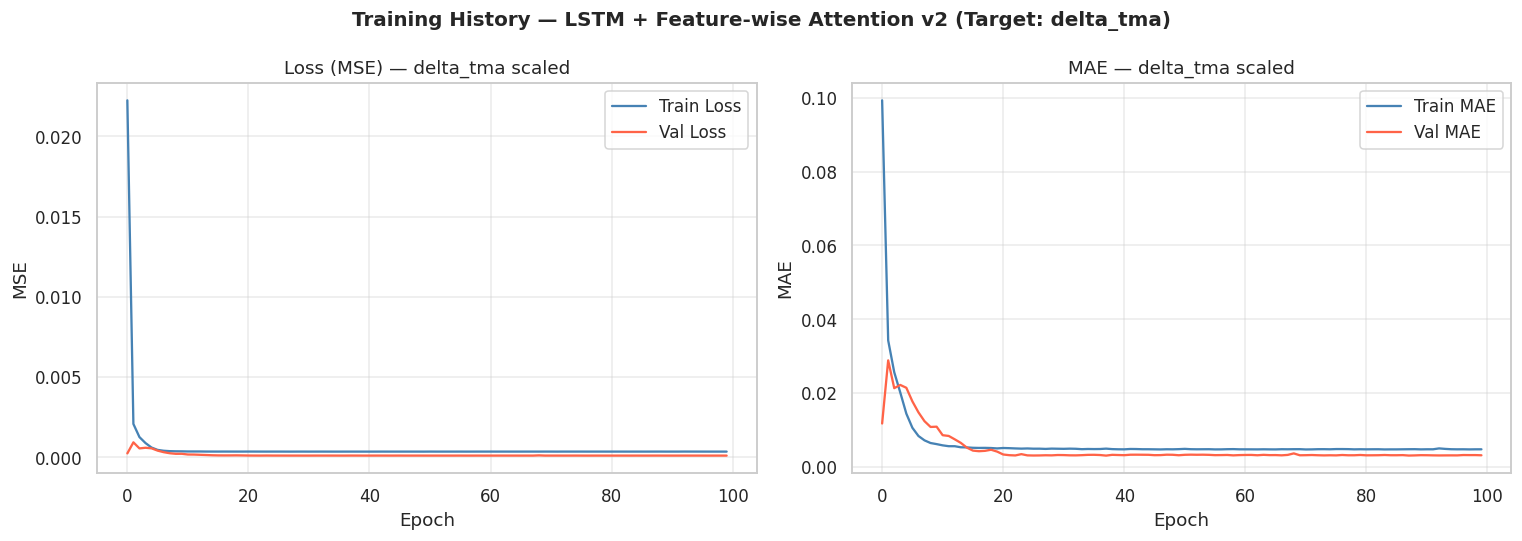

In [ ]:
# =============================================================================
# 11. PLOT TRAINING HISTORY
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — LSTM + Feature-wise Attention v2 (Target: delta_tma)',
             fontsize=13, fontweight='bold')

train_loss_key = 'output_loss' if 'output_loss' in history.history else 'loss'
val_loss_key   = 'val_output_loss' if 'val_output_loss' in history.history else 'val_loss'
train_mae_key  = 'output_mae' if 'output_mae' in history.history else 'mae'
val_mae_key    = 'val_output_mae' if 'val_output_mae' in history.history else 'val_mae'

axes[0].plot(history.history[train_loss_key], label='Train Loss', color='steelblue', lw=1.5)
axes[0].plot(history.history[val_loss_key],   label='Val Loss',   color='tomato',    lw=1.5)
axes[0].set_title('Loss (MSE) — delta_tma scaled')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.4)

if train_mae_key in history.history:
    axes[1].plot(history.history[train_mae_key], label='Train MAE', color='steelblue', lw=1.5)
    axes[1].plot(history.history[val_mae_key],   label='Val MAE',   color='tomato',    lw=1.5)
axes[1].set_title('MAE — delta_tma scaled')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_history.png', bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# 12. PREDIKSI, INVERSE TRANSFORM & REKONSTRUKSI TMA ABSOLUT
# =============================================================================
#
# [PERUBAHAN DARI v1 — BAGIAN KRUSIAL]
#
# Model menghasilkan delta_tma scaled → inverse transform → delta_tma (m)
#
# Rekonstruksi TMA absolut (1-step ahead, teacher forcing):
#   tma_pred(t) = tma_actual(t-1) + delta_pred(t)
#
# Teacher forcing: tma_actual(t-1) yang digunakan adalah nilai AKTUAL
# (bukan nilai prediksi sebelumnya). Ini merupakan evaluasi 1-step ahead
# yang valid karena pada saat prediksi t, kita mengetahui TMA aktual pada t-1.
#
# Metrik regresi dihitung pada TMA ABSOLUT hasil rekonstruksi, bukan pada delta.

def predict_and_reconstruct(X_input, tma_prev, label=''):
    """
    Prediksi delta_tma → inverse transform → rekonstruksi TMA absolut.

    Parameters
    ----------
    X_input  : (samples, LOOK_BACK, n_features)
    tma_prev : (samples,) — TMA aktual pada t-1 (teacher forcing)
    label    : str — label untuk logging

    Returns
    -------
    tma_reconstructed : (samples,) — TMA absolut hasil rekonstruksi
    delta_pred        : (samples,) — delta TMA yang diprediksi (m)
    attn              : (samples, LOOK_BACK, n_features) — bobot attention
    """
    # Prediksi model → delta_tma scaled
    delta_scaled, attn = model.predict(X_input, verbose=0)

    # Inverse transform → delta_tma dalam meter
    delta_pred = scaler_target.inverse_transform(delta_scaled).flatten()

    # Rekonstruksi TMA absolut: 1-step ahead, teacher forcing
    # tma_pred(t) = tma_actual(t-1) + delta_pred(t)
    tma_reconstructed = tma_prev + delta_pred

    if label:
        print(f'  {label:12s}: delta range [{delta_pred.min():.4f}, {delta_pred.max():.4f}] m'
              f' | TMA rekonstruksi [{tma_reconstructed.min():.3f}, {tma_reconstructed.max():.3f}] m')

    return tma_reconstructed, delta_pred, attn


print('Membuat prediksi dan rekonstruksi TMA absolut...')
print('[1-step ahead evaluation dengan teacher forcing — TMA actual(t-1) digunakan]')

pred_train, delta_train, attn_train = predict_and_reconstruct(X_train, tma_prev_train, 'Train')
pred_val,   delta_val,   attn_val   = predict_and_reconstruct(X_val,   tma_prev_val,   'Val')
pred_test,  delta_test,  attn_test  = predict_and_reconstruct(X_test,  tma_prev_test,  'Test')

# true_* = TMA absolut aktual (untuk evaluasi)
true_train = tma_true_train
true_val   = tma_true_val
true_test  = tma_true_test

print(f'\nRekonstruksi selesai.')
print(f'  Train  : {len(pred_train)} sampel | aktual [{true_train.min():.3f}, {true_train.max():.3f}] m')
print(f'  Val    : {len(pred_val)} sampel | aktual [{true_val.min():.3f}, {true_val.max():.3f}] m')
print(f'  Test   : {len(pred_test)} sampel | aktual [{true_test.min():.3f}, {true_test.max():.3f}] m')


Membuat prediksi dan rekonstruksi TMA absolut...
[1-step ahead evaluation dengan teacher forcing — TMA actual(t-1) digunakan]
  Train       : delta range [-0.0111, 0.0381] m | TMA rekonstruksi [78.035, 88.733] m
  Val         : delta range [-0.0114, 0.0319] m | TMA rekonstruksi [82.528, 87.800] m
  Test        : delta range [-0.0111, 0.0333] m | TMA rekonstruksi [84.173, 88.151] m

Rekonstruksi selesai.
  Train  : 5956 sampel | aktual [78.040, 88.700] m
  Val    : 1276 sampel | aktual [82.520, 87.790] m
  Test   : 1277 sampel | aktual [84.180, 88.130] m


In [ ]:
# =============================================================================
# 13. EVALUASI REGRESI (PADA TMA ABSOLUT HASIL REKONSTRUKSI)
# =============================================================================
#
# [PERUBAHAN DARI v1]
# Semua metrik dihitung pada TMA ABSOLUT (hasil rekonstruksi teacher forcing),
# bukan pada nilai delta. Ini memastikan interpretasi metrik yang intuitif (meter).

print('\n[Catatan: RMSE, MAE, MAPE, R², NSE dihitung pada TMA ABSOLUT hasil rekonstruksi]')
print('[Bukan pada nilai delta_tma — ini evaluasi 1-step ahead]')

metrics_train = compute_regression_metrics(true_train, pred_train, 'TRAIN (TMA Absolut)')
metrics_val   = compute_regression_metrics(true_val,   pred_val,   'VALIDATION (TMA Absolut)')
metrics_test  = compute_regression_metrics(true_test,  pred_test,  'TEST (TMA Absolut) — FINAL')
# Tabel ringkasan
summary = pd.DataFrame({
    'Set'      : ['Train', 'Validation', 'Test'],
    'Samples'  : [len(true_train), len(true_val), len(true_test)],
    'RMSE (m)' : [metrics_train['rmse'], metrics_val['rmse'], metrics_test['rmse']],
    'MAE (m)'  : [metrics_train['mae'],  metrics_val['mae'],  metrics_test['mae']],
    'MAPE (%)' : [metrics_train['mape'], metrics_val['mape'], metrics_test['mape']],
    'R²'       : [metrics_train['r2'],   metrics_val['r2'],   metrics_test['r2']],
    'NSE'      : [metrics_train['nse'],  metrics_val['nse'],  metrics_test['nse']],
})

float_cols = ['RMSE (m)', 'MAE (m)', 'MAPE (%)', 'R²', 'NSE']
print('\n' + summary.to_string(index=False))
summary.style \
    .format({c: '{:.4f}' for c in float_cols}) \
    .background_gradient(subset=['NSE', 'R²'], cmap='YlGn') \
    .background_gradient(subset=['RMSE (m)', 'MAE (m)'], cmap='YlOrRd_r') \
    .set_caption('Ringkasan Metrik Evaluasi Regresi — TMA Absolut (v2)')



[Catatan: RMSE, MAE, MAPE, R², NSE dihitung pada TMA ABSOLUT hasil rekonstruksi]
[Bukan pada nilai delta_tma — ini evaluasi 1-step ahead]

  TRAIN (TMA Absolut)
  RMSE : 0.1217 m
  MAE  : 0.0263 m
  MAPE : 0.0305 %
  R²   : 0.9960
  NSE  : 0.9960

  VALIDATION (TMA Absolut)
  RMSE : 0.0671 m
  MAE  : 0.0208 m
  MAPE : 0.0244 %
  R²   : 0.9986
  NSE  : 0.9986

  TEST (TMA Absolut) — FINAL
  RMSE : 0.0744 m
  MAE  : 0.0265 m
  MAPE : 0.0305 %
  R²   : 0.9954
  NSE  : 0.9954

       Set  Samples  RMSE (m)  MAE (m)  MAPE (%)       R²      NSE
     Train     5956  0.121700 0.026295  0.030549 0.996014 0.996014
Validation     1276  0.067144 0.020803  0.024394 0.998592 0.998592
      Test     1277  0.074419 0.026474  0.030534 0.995402 0.995402


,Set,Samples,RMSE (m),MAE (m),MAPE (%),R²,NSE
0,Train,5956,0.1217,0.0263,0.0305,0.9960,0.9960
1,Validation,1276,0.0671,0.0208,0.0244,0.9986,0.9986
2,Test,1277,0.0744,0.0265,0.0305,0.9954,0.9954



[BARU v2] Threshold TMA Bahaya : 87.630 m
  = Persentil ke-90 dari seluruh dataset tma_m (8557 baris)
  Persentase BAHAYA aktual — Train : 4.6%
  Persentase BAHAYA aktual — Val   : 12.5%
  Persentase BAHAYA aktual — Test  : 35.1%

--- Early Warning Metrics (TRAIN) ---
  Threshold : 87.630 m
  Accuracy  : 0.9673
  Recall    : 0.6473
  Precision : 0.6449
  F1-Score  : 0.6461

--- Early Warning Metrics (VALIDATION) ---
  Threshold : 87.630 m
  Accuracy  : 0.8918
  Recall    : 0.2188
  Precision : 0.7292
  F1-Score  : 0.3365

--- Early Warning Metrics (TEST) ---
  Threshold : 87.630 m
  Accuracy  : 0.9718
  Recall    : 0.9420
  Precision : 0.9769
  F1-Score  : 0.9591


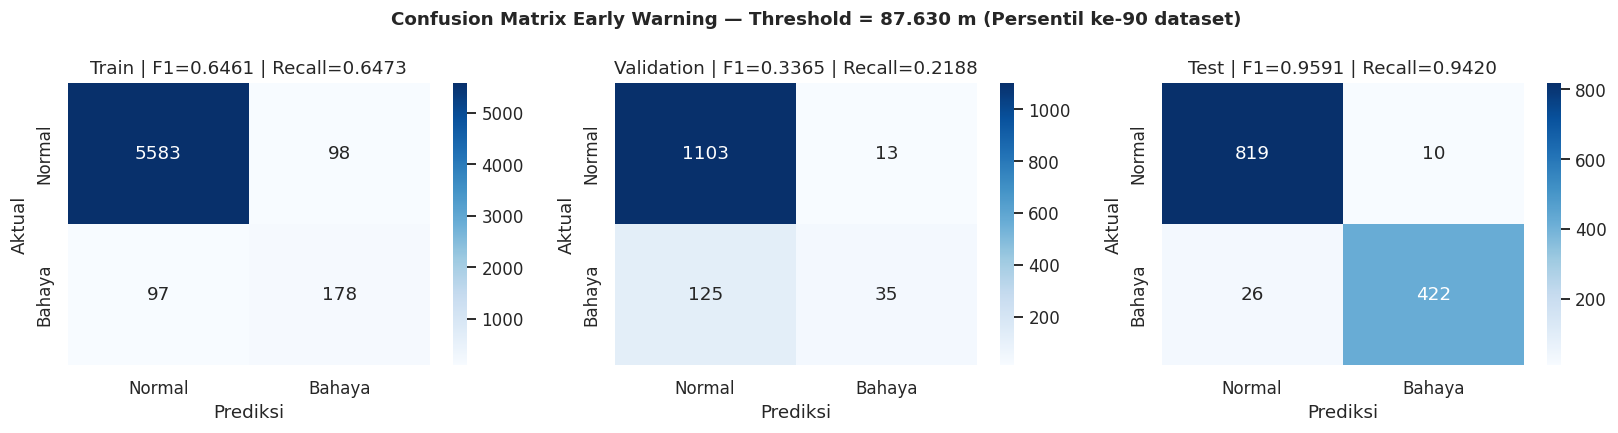

In [ ]:
# =============================================================================
# 14. EVALUASI EARLY WARNING (KLASIFIKASI)
# =============================================================================
#
# [PERUBAHAN DARI v1]
# Threshold: persentil ke-90 dari SELURUH dataset tma_m (bukan mean+1.5σ test set).
# Alasan: threshold dari test set berpotensi data leakage secara konseptual.
#         Persentil ke-90 dari dataset penuh lebih robust dan tidak bias.

# [BARU] Persentil ke-90 dari seluruh tma_m dataset
threshold = float(np.percentile(df_model['tma_m'].values, 90))

print(f'\n[BARU v2] Threshold TMA Bahaya : {threshold:.3f} m')
print(f'  = Persentil ke-90 dari seluruh dataset tma_m ({len(df_model)} baris)')
print(f'  Persentase BAHAYA aktual — Train : {(true_train >= threshold).mean()*100:.1f}%')
print(f'  Persentase BAHAYA aktual — Val   : {(true_val >= threshold).mean()*100:.1f}%')
print(f'  Persentase BAHAYA aktual — Test  : {(true_test >= threshold).mean()*100:.1f}%')

clf_train = compute_classification_metrics(true_train, pred_train, threshold, 'TRAIN')
clf_val   = compute_classification_metrics(true_val,   pred_val,   threshold, 'VALIDATION')
clf_test  = compute_classification_metrics(true_test,  pred_test,  threshold, 'TEST')

# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Confusion Matrix Early Warning — Threshold = {threshold:.3f} m '
             f'(Persentil ke-90 dataset)',
             fontsize=12, fontweight='bold')

for ax, (clf, label) in zip(axes, [
    (clf_train, 'Train'),
    (clf_val,   'Validation'),
    (clf_test,  'Test'),
]):
    sns.heatmap(
        clf['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Bahaya'],
        yticklabels=['Normal', 'Bahaya'],
        ax=ax
    )
    ax.set_title(f'{label} | F1={clf["f1"]:.4f} | Recall={clf["recall"]:.4f}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/confusion_matrix.png', bbox_inches='tight')
plt.show()

Rata-rata bobot attention per fitur (test set):
Shape: (5,)
Sum bobot: 1.0000 (seharusnya mendekati 1)

Ranking bobot attention:
          fitur    bobot
curah_hujan_log 0.572750
        smd_avg 0.159167
     cuaca_kode 0.097945
 delta_tma_lag1 0.087775
       jam_kode 0.082365


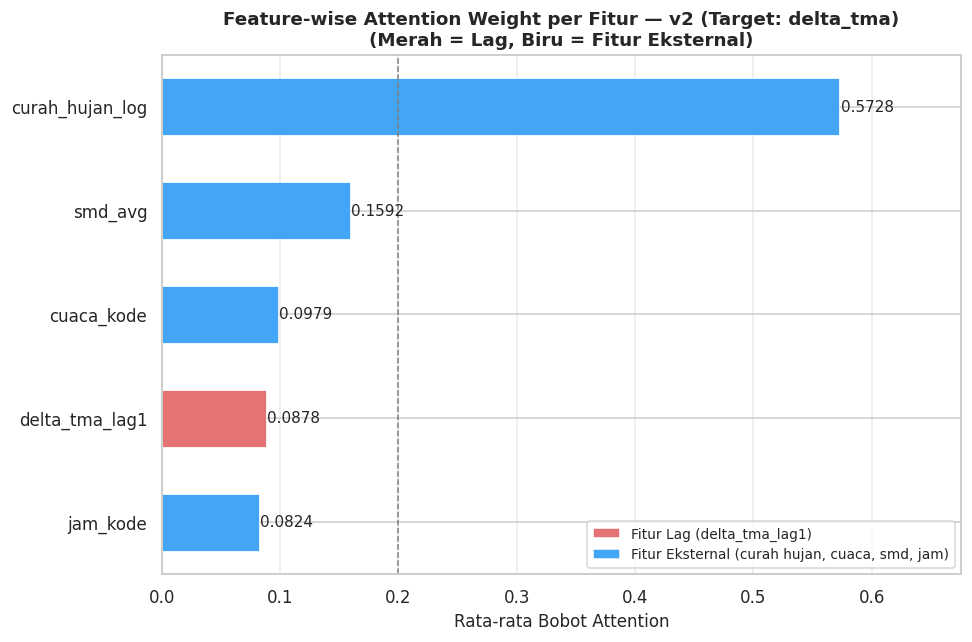


Total bobot fitur lag        : 0.0878 (8.8%)
Total bobot fitur eksternal  : 0.9122 (91.2%)
Fitur dengan bobot tertinggi : curah_hujan_log (0.5728)


In [ ]:
# =============================================================================
# 15. VISUALISASI ATTENTION WEIGHT PER FITUR
# =============================================================================
#
# [PERUBAHAN DARI v1]
# Fitur: 5 fitur baru (bukan 11 fitur lama)
# Warna: delta_tma_lag1 = merah (fitur lag), sisanya = biru (fitur eksternal)
#
# Hipotesis: setelah target diubah ke delta_tma, bobot attention akan lebih
# merata dan lebih besar pada curah_hujan_log, smd_avg, dan cuaca_kode karena
# fitur-fitur ini berkorelasi dengan perubahan TMA (bukan nilai absolut).

# Rata-rata bobot attention dari seluruh test set
# attn_test shape: (samples, LOOK_BACK, n_features)
# Rata-rata atas dimensi samples dan timesteps → (n_features,)
avg_attention = np.mean(attn_test, axis=(0, 1))   # shape: (5,)

print('Rata-rata bobot attention per fitur (test set):')
print(f'Shape: {avg_attention.shape}')
print(f'Sum bobot: {avg_attention.sum():.4f} (seharusnya mendekati 1)')

# Dict fitur → bobot
attention_dict = dict(zip(FEATURE_COLS, avg_attention))
attention_df   = pd.DataFrame({
    'fitur' : FEATURE_COLS,
    'bobot' : avg_attention
}).sort_values('bobot', ascending=False).reset_index(drop=True)

print('\nRanking bobot attention:')
print(attention_df.to_string(index=False))

# Definisi kelompok fitur
LAG_FEATURES = {'delta_tma_lag1'}
EXT_FEATURES = {'curah_hujan_log', 'cuaca_kode', 'smd_avg', 'jam_kode'}

colors = [
    '#e57373' if f in LAG_FEATURES else '#42a5f5'
    for f in attention_df['fitur']
]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    attention_df['fitur'][::-1],
    attention_df['bobot'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5,
    height=0.55
)

for bar, val in zip(bars, attention_df['bobot'][::-1]):
    ax.text(
        bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}', va='center', ha='left', fontsize=10
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e57373', label='Fitur Lag (delta_tma_lag1)'),
    Patch(facecolor='#42a5f5', label='Fitur Eksternal (curah hujan, cuaca, smd, jam)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.axvline(1 / n_features, color='gray', ls='--', lw=1, label=f'Uniform (1/{n_features})')
ax.set_xlabel('Rata-rata Bobot Attention', fontsize=11)
ax.set_title(
    'Feature-wise Attention Weight per Fitur — v2 (Target: delta_tma)\n'
    '(Merah = Lag, Biru = Fitur Eksternal)',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(0, attention_df['bobot'].max() * 1.18)
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/attention_weights_chart.png', bbox_inches='tight', dpi=150)
plt.show()

lag_total = sum(attention_df.loc[attention_df['fitur'].isin(LAG_FEATURES), 'bobot'])
ext_total = sum(attention_df.loc[attention_df['fitur'].isin(EXT_FEATURES), 'bobot'])
print(f'\nTotal bobot fitur lag        : {lag_total:.4f} ({lag_total*100:.1f}%)')
print(f'Total bobot fitur eksternal  : {ext_total:.4f} ({ext_total*100:.1f}%)')
print(f'Fitur dengan bobot tertinggi : {attention_df.iloc[0]["fitur"]} ({attention_df.iloc[0]["bobot"]:.4f})')


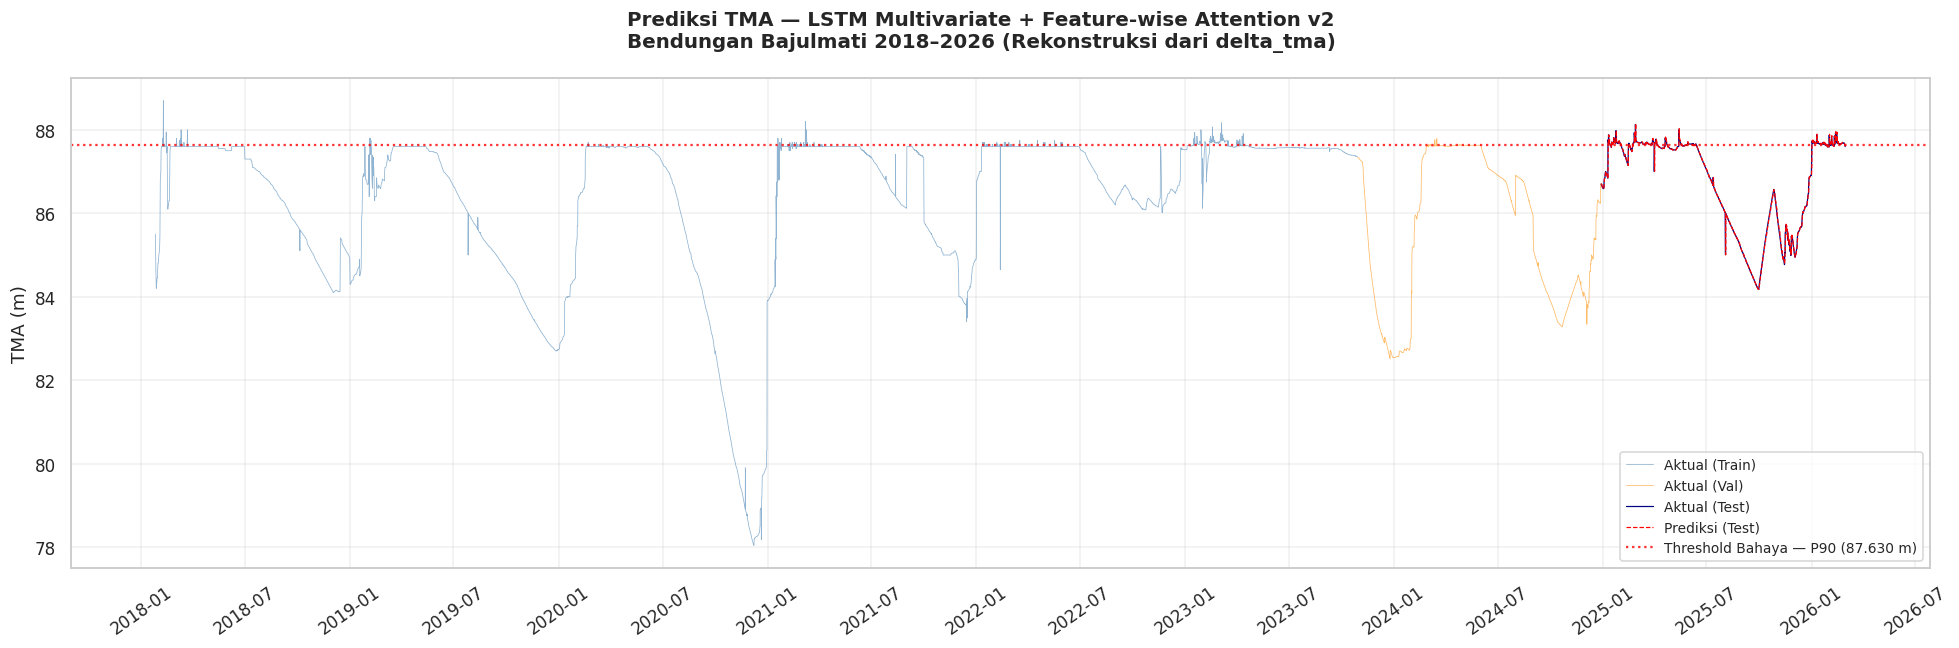

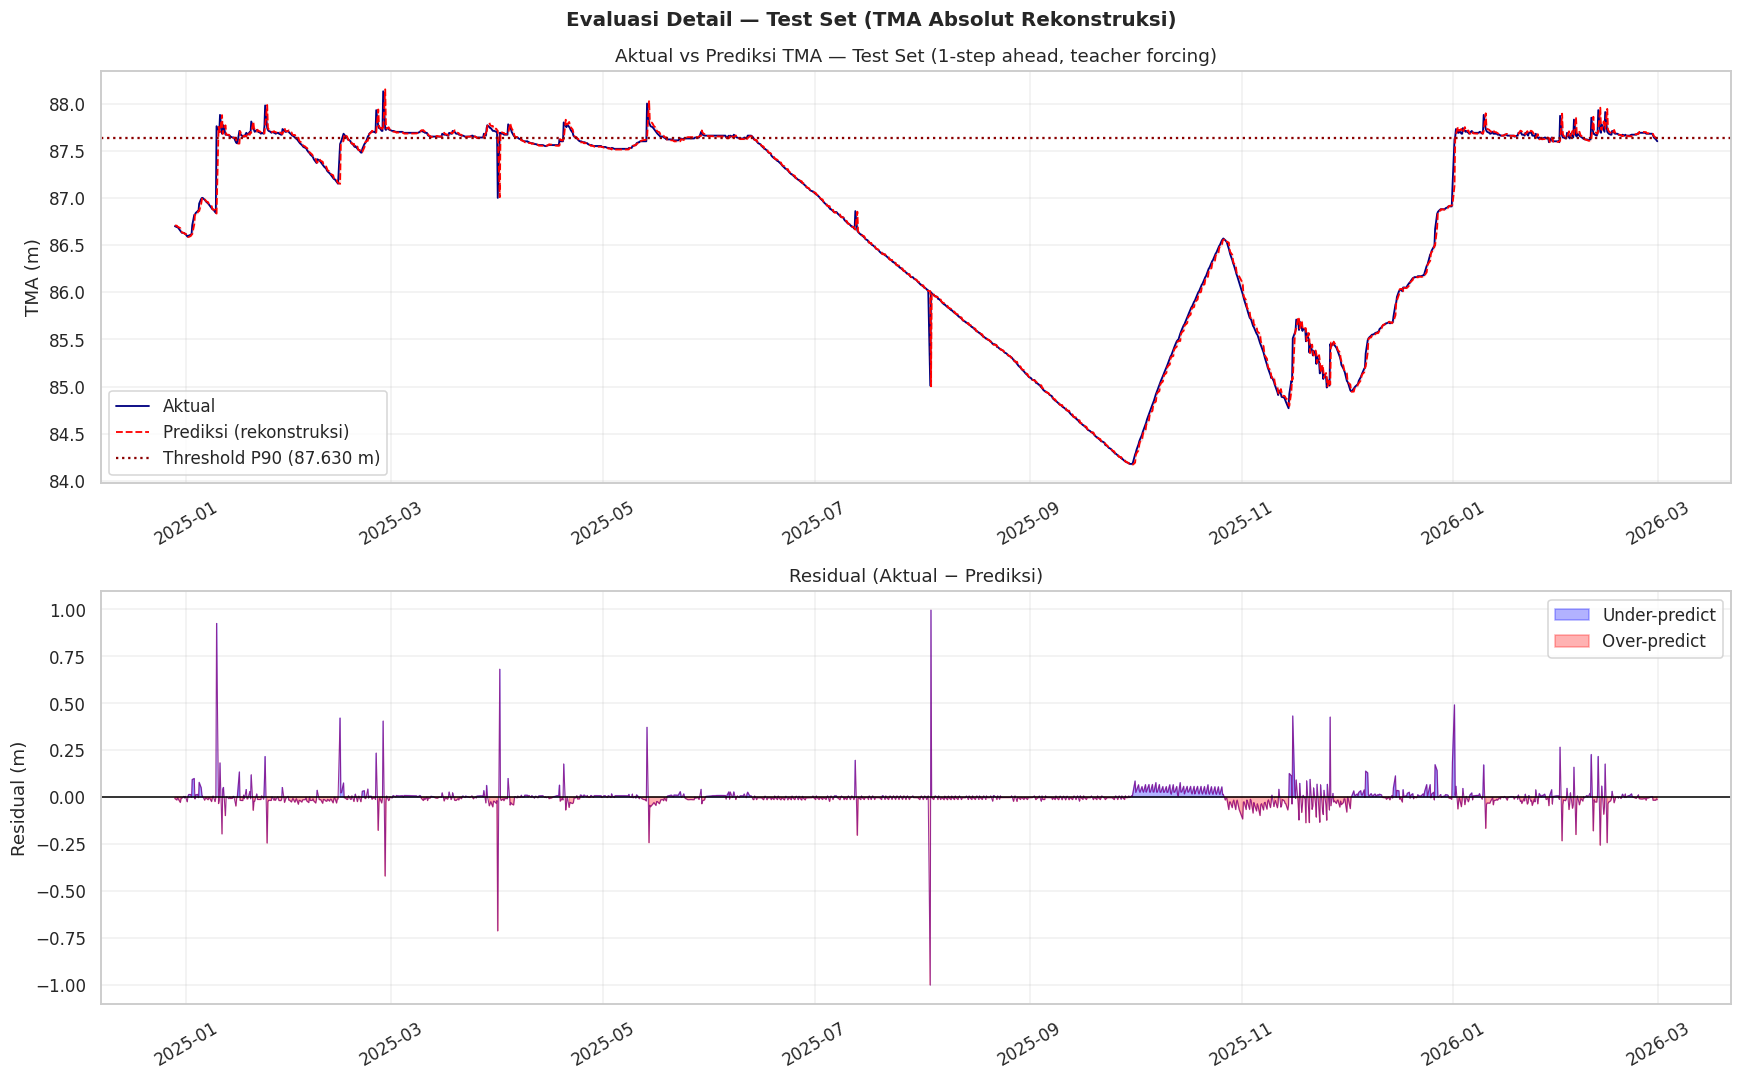

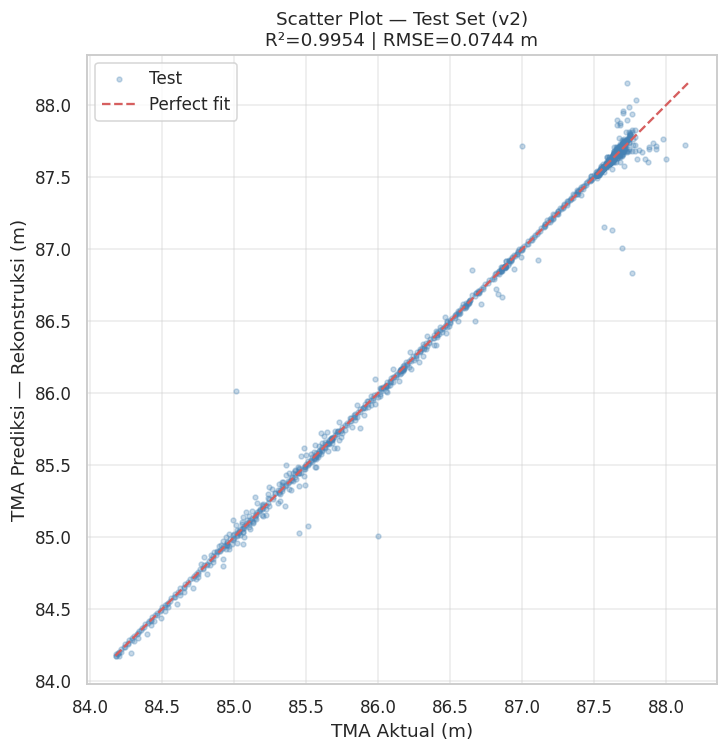

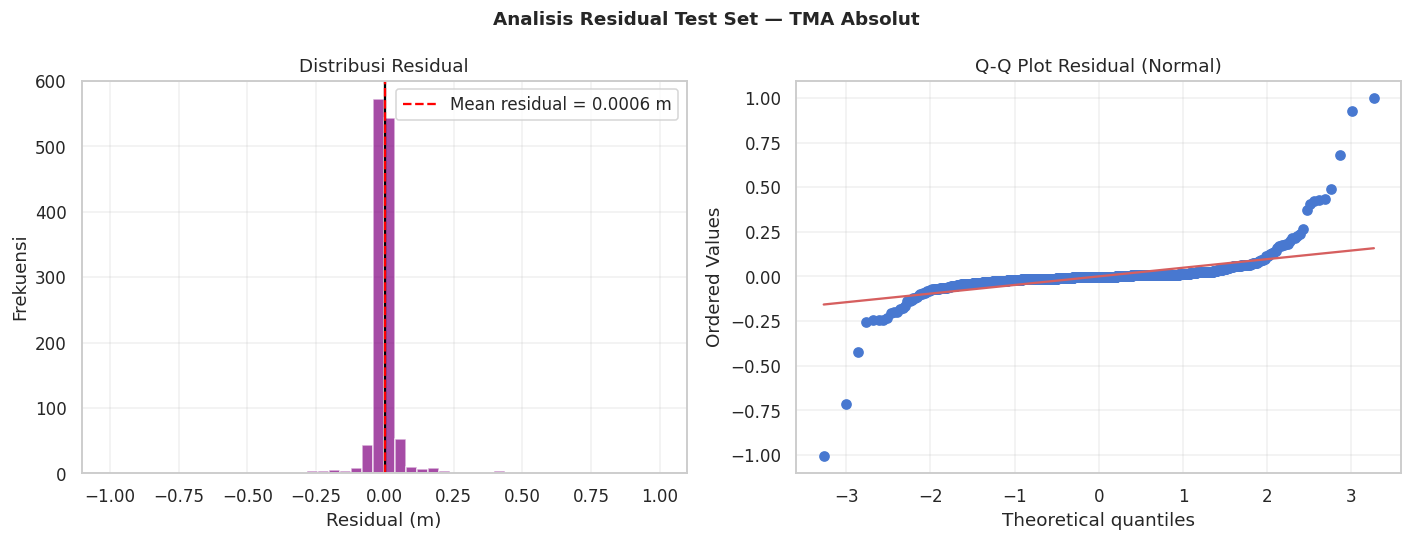

In [ ]:
# =============================================================================
# 16. VISUALISASI PREDIKSI
# =============================================================================

# --- 16a. Full Timeline ---
fig, ax = plt.subplots(figsize=(18, 6))
fig.suptitle(
    'Prediksi TMA — LSTM Multivariate + Feature-wise Attention v2\n'
    'Bendungan Bajulmati 2018–2026 (Rekonstruksi dari delta_tma)',
    fontsize=13, fontweight='bold'
)

ax.plot(dt_train, true_train, color='steelblue',  lw=0.5, alpha=0.6, label='Aktual (Train)')
ax.plot(dt_val,   true_val,   color='darkorange', lw=0.5, alpha=0.6, label='Aktual (Val)')
ax.plot(dt_test,  true_test,  color='navy',       lw=0.8, label='Aktual (Test)')
ax.plot(dt_test,  pred_test,  color='red',        lw=0.8, ls='--', label='Prediksi (Test)')

ax.axhline(threshold, color='red', ls=':', lw=1.5, alpha=0.8,
           label=f'Threshold Bahaya — P90 ({threshold:.3f} m)')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.tick_params(axis='x', rotation=35)
ax.set_ylabel('TMA (m)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/pred_full_timeline.png', bbox_inches='tight', dpi=130)
plt.show()

# --- 16b. Zoom Test Set ---
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Evaluasi Detail — Test Set (TMA Absolut Rekonstruksi)', fontsize=13, fontweight='bold')

axes[0].plot(dt_test, true_test, color='navy', lw=1.2, label='Aktual')
axes[0].plot(dt_test, pred_test, '--', color='red', lw=1.2, label='Prediksi (rekonstruksi)')
axes[0].axhline(threshold, color='darkred', ls=':', lw=1.5,
                label=f'Threshold P90 ({threshold:.3f} m)')
axes[0].fill_between(dt_test, true_test, pred_test, alpha=0.15, color='tomato')
axes[0].set_title('Aktual vs Prediksi TMA — Test Set (1-step ahead, teacher forcing)')
axes[0].set_ylabel('TMA (m)')
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = true_test - pred_test
axes[1].plot(dt_test, residuals, color='purple', lw=0.7, alpha=0.8)
axes[1].axhline(0, color='black', lw=1)
axes[1].fill_between(dt_test, residuals, 0,
                     where=(residuals > 0), alpha=0.3, color='blue', label='Under-predict')
axes[1].fill_between(dt_test, residuals, 0,
                     where=(residuals < 0), alpha=0.3, color='red', label='Over-predict')
axes[1].set_title('Residual (Aktual − Prediksi)')
axes[1].set_ylabel('Residual (m)')
axes[1].legend()
axes[1].grid(alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/pred_test_detail.png', bbox_inches='tight')
plt.show()

# --- 16c. Scatter Plot ---
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(true_test, pred_test, alpha=0.3, s=10, color='steelblue', label='Test')
lims = [min(true_test.min(), pred_test.min()), max(true_test.max(), pred_test.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')

ax.set_xlabel('TMA Aktual (m)')
ax.set_ylabel('TMA Prediksi — Rekonstruksi (m)')
ax.set_title(f'Scatter Plot — Test Set (v2)\nR²={metrics_test["r2"]:.4f} | RMSE={metrics_test["rmse"]:.4f} m')
ax.legend()
ax.grid(alpha=0.4)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/pred_scatter.png', bbox_inches='tight')
plt.show()

# --- 16d. [BARU] Distribusi Residual ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analisis Residual Test Set — TMA Absolut', fontsize=12, fontweight='bold')

axes[0].hist(residuals, bins=50, color='purple', edgecolor='white', alpha=0.7)
axes[0].axvline(0, color='black', lw=1.5)
axes[0].axvline(residuals.mean(), color='red', lw=1.5, ls='--',
                label=f'Mean residual = {residuals.mean():.4f} m')
axes[0].set_title('Distribusi Residual')
axes[0].set_xlabel('Residual (m)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(alpha=0.3)

from scipy import stats as scipy_stats
scipy_stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot Residual (Normal)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/pred_residual_analysis.png', bbox_inches='tight')
plt.show()


In [ ]:
# =============================================================================
# 17. SIMPAN SEMUA OUTPUT KE FOLDER models/
# =============================================================================
print('Menyimpan model dan artefak...')

# 1. Model terbaik sudah disimpan oleh ModelCheckpoint
assert os.path.exists(f'{MODEL_DIR}/best_model.keras'), 'Model keras tidak ditemukan!'
print(f'  ✓ models/best_model.keras')

# 2. Scaler semua kolom (delta_tma + 5 fitur)
with open(f'{MODEL_DIR}/scaler_all.pkl', 'wb') as f:
    pickle.dump(scaler_all, f)
print(f'  ✓ models/scaler_all.pkl')

# 3. Scaler target (delta_tma) untuk inverse transform
with open(f'{MODEL_DIR}/scaler_target.pkl', 'wb') as f:
    pickle.dump(scaler_target, f)
print(f'  ✓ models/scaler_target.pkl')

# 4. Daftar kolom
with open(f'{MODEL_DIR}/feature_cols.pkl', 'wb') as f:
    pickle.dump({
        'all_cols'    : ALL_COLS,
        'feature_cols': FEATURE_COLS,
        'target_col'  : TARGET_COL,
        'look_back'   : LOOK_BACK,
        'model_version': 'v2_delta_tma',
    }, f)
print(f'  ✓ models/feature_cols.pkl')

# 5. Rata-rata bobot attention test set — shape (n_features,)
np.save(f'{MODEL_DIR}/attention_weights.npy', avg_attention)
print(f'  ✓ models/attention_weights.npy  shape={avg_attention.shape}')

# 6. Seed history — LOOK_BACK baris terakhir data fitur training (untuk inferensi real-time)
#    Shape: (LOOK_BACK, n_features) = (48, 5)
seed_history = scaled_all[-(LOOK_BACK):, 1:]   # kolom fitur saja (bukan target di kolom 0)
np.save(f'{MODEL_DIR}/seed_history.npy', seed_history)
print(f'  ✓ models/seed_history.npy  shape={seed_history.shape}')

# 7. Training metadata JSON
metadata = {
    'model_version'  : 'v2_delta_tma',
    'look_back'      : LOOK_BACK,
    'n_features'     : n_features,
    'feature_cols'   : FEATURE_COLS,
    'all_cols'       : ALL_COLS,
    'target_col'     : TARGET_COL,
    'threshold'      : round(threshold, 4),
    'threshold_method': 'percentile_90_full_dataset',
    'reconstruction' : '1-step-ahead teacher forcing: tma_pred(t) = tma_actual(t-1) + delta_pred(t)',
    'train_end_date' : train_end_date,
    'val_end_date'   : val_end_date,
    'metrics_on'     : 'TMA absolut rekonstruksi (bukan delta)',
    'metrics': {
        'train_rmse'  : round(metrics_train['rmse'], 4),
        'train_mae'   : round(metrics_train['mae'],  4),
        'train_r2'    : round(metrics_train['r2'],   4),
        'train_nse'   : round(metrics_train['nse'],  4),
        'val_rmse'    : round(metrics_val['rmse'],   4),
        'val_mae'     : round(metrics_val['mae'],    4),
        'val_r2'      : round(metrics_val['r2'],     4),
        'val_nse'     : round(metrics_val['nse'],    4),
        'test_rmse'   : round(metrics_test['rmse'],  4),
        'test_mae'    : round(metrics_test['mae'],   4),
        'test_mape'   : round(metrics_test['mape'],  4),
        'test_r2'     : round(metrics_test['r2'],    4),
        'test_nse'    : round(metrics_test['nse'],   4),
        'test_recall' : round(clf_test['recall'],    4),
        'test_f1'     : round(clf_test['f1'],        4),
        'test_precision': round(clf_test['precision'], 4),
    },
    'attention_weights': {f: round(float(w), 6) for f, w in attention_dict.items()},
    'trained_at'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'epochs_trained' : epochs_trained,
    'dataset_rows'   : len(df),
    'df_model_rows'  : len(df_model),
    'batch_size'     : BATCH_SIZE,
}

with open(f'{MODEL_DIR}/training_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'  ✓ models/training_metadata.json')

# --- Ringkasan Akhir ---
print('\n' + '='*55)
print('SEMUA OUTPUT BERHASIL DISIMPAN')
print('='*55)
print(f'Folder  : {os.path.abspath(MODEL_DIR)}')
print(f'Isi     :')
for fn in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, fn)
    fsize = os.path.getsize(fpath)
    print(f'  {fn:<40} {fsize/1024:8.1f} KB')

print(f'\n{"="*55}')
print('METRIK TEST SET FINAL (TMA Absolut Rekonstruksi)')
print(f'{"="*55}')
print(f'  RMSE     : {metadata["metrics"]["test_rmse"]:.4f} m')
print(f'  MAE      : {metadata["metrics"]["test_mae"]:.4f} m')
print(f'  MAPE     : {metadata["metrics"]["test_mape"]:.4f} %')
print(f'  R²       : {metadata["metrics"]["test_r2"]:.4f}')
print(f'  NSE      : {metadata["metrics"]["test_nse"]:.4f}')
print(f'  Recall   : {metadata["metrics"]["test_recall"]:.4f}')
print(f'  Precision: {metadata["metrics"]["test_precision"]:.4f}')
print(f'  F1       : {metadata["metrics"]["test_f1"]:.4f}')
print(f'  Threshold: {metadata["threshold"]:.3f} m (Persentil ke-90 dataset)')
print(f'{"="*55}')
print(f'\nCatatan: Evaluasi menggunakan 1-step ahead teacher forcing.')
print(f'  tma_pred(t) = tma_actual(t-1) + delta_pred(t)')

Menyimpan model dan artefak...
  ✓ models/best_model.keras
  ✓ models/scaler_all.pkl
  ✓ models/scaler_target.pkl
  ✓ models/feature_cols.pkl
  ✓ models/attention_weights.npy  shape=(5,)
  ✓ models/seed_history.npy  shape=(48, 5)
  ✓ models/training_metadata.json

SEMUA OUTPUT BERHASIL DISIMPAN
Folder  : /content/models
Isi     :
  attention_weights.npy                         0.1 KB
  attention_weights_chart.png                  75.8 KB
  best_model.keras                           1252.7 KB
  confusion_matrix.png                         65.3 KB
  eda_boxplot_tahun.png                        47.0 KB
  eda_correlation.png                          58.0 KB
  eda_distribusi.png                           64.6 KB
  eda_timeseries.png                          184.7 KB
  feature_cols.pkl                              0.2 KB
  pred_full_timeline.png                      130.8 KB
  pred_residual_analysis.png                   60.8 KB
  pred_scatter.png                             71.8 KB
  pred_t